<a href="https://colab.research.google.com/github/Chosencodes/Lung-Segmentation/blob/main/Lung_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# !pip install -U gdown
# !gdown https://drive.google.com/file/d/1I1LR7XjyEZ-VBQ-Xruh31V7xExMjlVvi/view?usp=drive_link -O /content/Task06_Lung.tar

In [ ]:
# !tar -xf /content/Task06_Lung.tar -C /content/

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

# !cp -r /content/Task06_Lung '/content/drive/MyDrive/Task06_Lung'

In [ ]:
# !du -sh '/content/drive/MyDrive/Task06_Lung'

In [16]:
from google.colab import drive
drive.mount('/content/drive')

!cp -r '/content/drive/MyDrive/Task06_Lung' '/content/Task06_Lung'

data_path = '/content/Task06_Lung'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls -la /content/Task06_Lung

In [31]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
import os

In [4]:
root = Path("/content/drive/MyDrive/Task06_Lung/imagesTr")
label = Path("/content/drive/MyDrive/Task06_Lung/labelsTr")

In [5]:
sample_path = next(root.glob("lung*.nii.gz"))
sample_label_path = label / sample_path.name

In [21]:
data = nib.load(sample_path)
label = nib.load(sample_label_path)

In [22]:
ct_scan = data.get_fdata()
mask = label.get_fdata().astype(np.uint8)

In [8]:
print(data.shape)
print(label.shape)

print(nib.aff2axcodes(data.affine))
print(nib.aff2axcodes(label.affine))
print(data.header.get_zooms())
print(np.unique(mask))

(512, 512, 252)
(512, 512, 252)
('L', 'A', 'S')
('L', 'A', 'S')
(np.float32(0.9375), np.float32(0.9375), np.float32(1.2450397))
[0 1]


In [9]:
tumor_pixels = np.sum(mask == 1)
background_pixels = np.sum(mask == 0)

print(tumor_pixels)
print(background_pixels)

print("Tumor %:", tumor_pixels / mask.size * 100)

338475
65721813
Tumor %: 0.5123728797549293


In [35]:
# for i, f in enumerate(files):
#     print(i, f)

Patient: lung_001.nii.gz
Tumor slices: [231 232 233 234 235 236 237 238 239 240 241 242 243 244 245 246 247 248
 250]


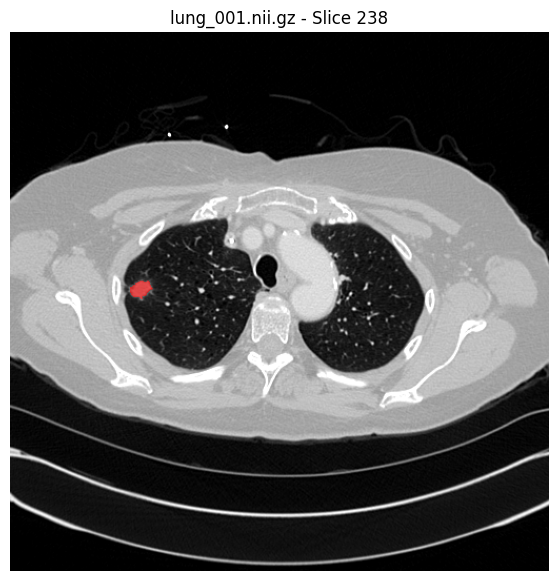

In [36]:
case = "lung_001.nii.gz"
print("Patient:", case)

image = nib.load(f"/content/Task06_Lung/imagesTr/{case}").get_fdata()
label = nib.load(f"/content/Task06_Lung/labelsTr/{case}").get_fdata().astype(np.uint8)

tumor_slices = np.where(label.sum(axis=(0, 1)) > 0)[0]

print("Tumor slices:", tumor_slices)

z = tumor_slices[np.argmax(label.sum(axis=(0, 1))[tumor_slices])]

plt.figure(figsize=(7,7))

plt.imshow(np.clip(image[:, :, z], -1000, 400).T,
           cmap="gray",
           origin="lower")

plt.imshow(np.ma.masked_where(label[:, :, z] == 0,
                              label[:, :, z]).T,
           cmap="autumn",
           alpha=0.6,
           origin="lower")

plt.title(f"{case} - Slice {z}")
plt.axis("off")
plt.show()

# **Preprocessing**

In [17]:
!pip install torchio nibabel scikit-learn tqdm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.6/203.6 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 21.8 MB/s eta 0:00:00


In [18]:
import torchio as tio
import torch
from pathlib import Path
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader